# Análisis de Patrones Temporales y EDA (Exploratory Data Analysis)

Este notebook aborda la **Issue #17**. El objetivo es entender los patrones de contaminación en Liverpool (PM2.5 y PM10) utilizando el dataset estandarizado (`sensors_definitivo.csv`). Analizaremos los datos en diferentes resoluciones temporales (horaria, diaria, semanal y estacional) para identificar picos y regularidades.

## Objetivos
1. **Resampling Temporal**: Agregar los datos a medias horarias, diarias y mensuales.
2. **Análisis Ciclo Diario**: Identificar picos (correlación con *rush hours*).
3. **Análisis Semanal**: Días laborables vs. fines de semana.
4. **Análisis Estacional**: Variaciones entre meses.
5. **Outliers Temporales**: Eventos extremos.


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook")
plt.rcParams['figure.figsize'] = (12, 6)

# Asegurar carpeta de outputs
os.makedirs('../../outputs/figures/eda', exist_ok=True)

# Cargar dataset definitivo
df = pd.read_csv('../../data/processed/sensors_definitivo.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

# Extraer componentes temporales para análisis ágil
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek # 0=Lunes, 6=Domingo
df['is_weekend'] = df['day_of_week'] >= 5
df['month'] = df['datetime'].dt.month
df['year'] = df['datetime'].dt.year
df['date'] = df['datetime'].dt.date

print(f"Dataset cargado: {len(df):,} registros")
print(f"Periodo: {df['datetime'].min()} al {df['datetime'].max()}")
df.head()


Dataset cargado: 1,537,060 registros
Periodo: 2021-03-20 07:30:00 al 2025-04-01 11:30:00


,datetime,sensor_id,Temperature,Humidity,PM1.0,PM2.5,PM10,lat,lon,label,tipo,hour,day_of_week,is_weekend,month,year,date
0,2021-10-28 05:00:00,f008d1cc04ec,19.030000,61.175000,1.409908,4.452372,14.182025,-2.98279,53.4397,Kirkdale station,valido,5,3,False,10,2021,2021-10-28
1,2021-10-28 05:30:00,f008d1cc04ec,19.019615,61.237173,1.398274,4.407409,14.075734,-2.98279,53.4397,Kirkdale station,valido,5,3,False,10,2021,2021-10-28
2,2021-10-28 06:00:00,f008d1cc04ec,19.009231,61.299346,1.386641,4.362447,13.969443,-2.98279,53.4397,Kirkdale station,valido,6,3,False,10,2021,2021-10-28
3,2021-10-28 06:30:00,f008d1cc04ec,18.998846,61.361519,1.375008,4.317484,13.863152,-2.98279,53.4397,Kirkdale station,valido,6,3,False,10,2021,2021-10-28
4,2021-10-28 07:00:00,f008d1cc04ec,18.988462,61.423692,1.363375,4.272522,13.756861,-2.98279,53.4397,Kirkdale station,valido,7,3,False,10,2021,2021-10-28


## 1. Evolución Temporal (Time Series Plot)

Vamos a agregar los datos a nivel de toda la ciudad (promediando todos los sensores) por semana y mes para ver las tendencias generales de $PM_{2.5}$ y $PM_{10}$ a lo largo de los años.

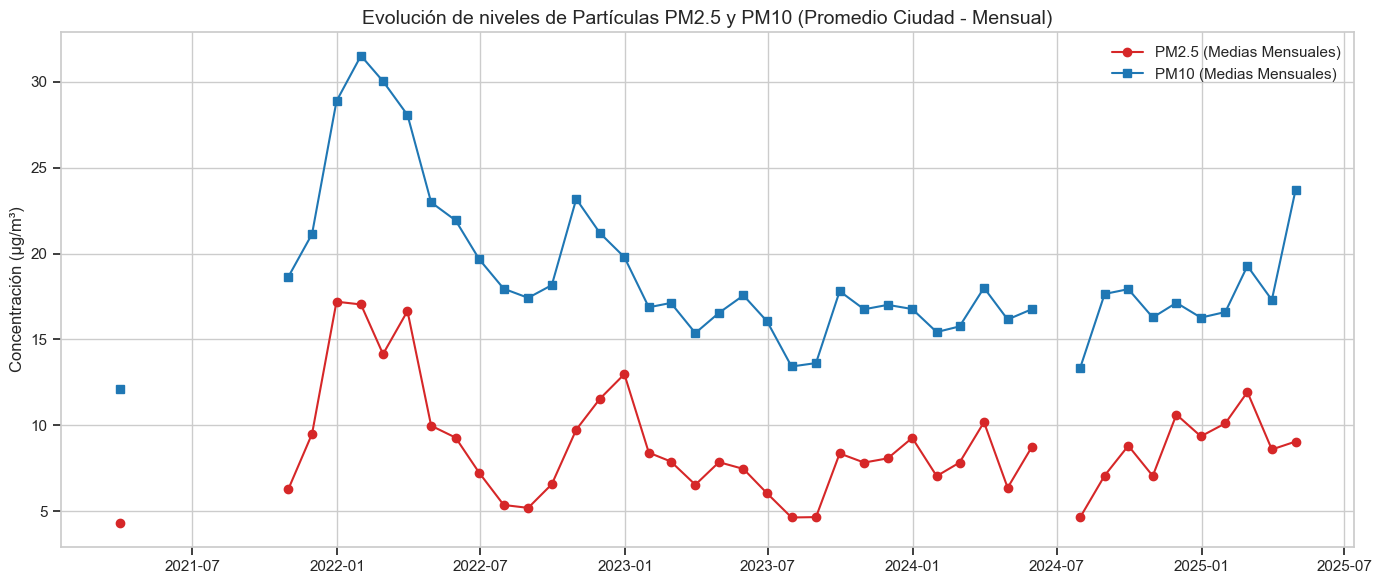

In [27]:
# Promedio de toda la ciudad
city_avg = df.groupby('datetime')[['PM2.5', 'PM10']].mean().reset_index()

# Remuestreo mensual
city_monthly = city_avg.set_index('datetime').resample('ME').mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(city_monthly.index, city_monthly['PM2.5'], label='PM2.5 (Medias Mensuales)', color='#d62728', marker='o')
ax.plot(city_monthly.index, city_monthly['PM10'], label='PM10 (Medias Mensuales)', color='#1f77b4', marker='s')

ax.set_title("Evolución de niveles de Partículas PM2.5 y PM10 (Promedio Ciudad - Mensual)", fontsize=14)
ax.set_ylabel("Concentración (µg/m³)")
ax.legend()
plt.tight_layout()
plt.savefig('../../outputs/figures/eda/ts_monthly_pollution.png')
plt.show()


## 2. Análisis del Ciclo Diario (Rush Hours)

El tráfico es uno de los mayores emisores locales. Veamos la concentración media de partículas en cada hora del día para identificar las horas punta (*rush hours*).

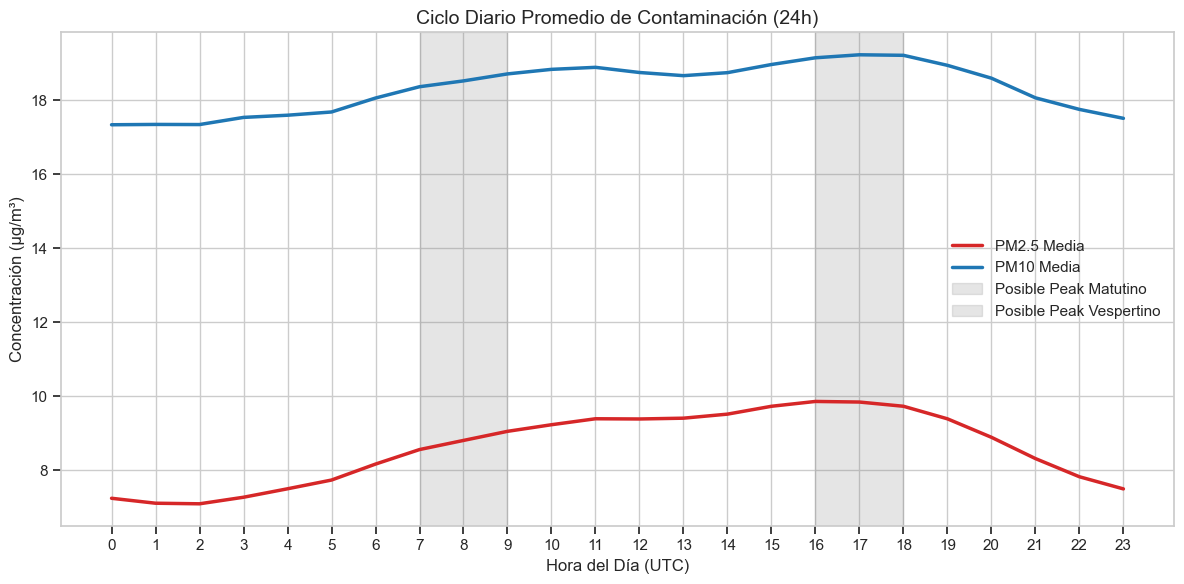

In [28]:
# Agrupar por hora
hourly_avg = df.groupby('hour')[['PM2.5', 'PM10', 'Temperature']].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(hourly_avg['hour'], hourly_avg['PM2.5'], label='PM2.5 Media', color='#d62728', linewidth=2.5)
ax.plot(hourly_avg['hour'], hourly_avg['PM10'], label='PM10 Media', color='#1f77b4', linewidth=2.5)

# Zonas de tráfico (aprox. 7-9 y 16-18)
ax.axvspan(7, 9, color='gray', alpha=0.2, label='Posible Peak Matutino')
ax.axvspan(16, 18, color='gray', alpha=0.2, label='Posible Peak Vespertino')

ax.set_xticks(range(0, 24))
ax.set_title("Ciclo Diario Promedio de Contaminación (24h)", fontsize=14)
ax.set_xlabel("Hora del Día (UTC)")
ax.set_ylabel("Concentración (µg/m³)")
ax.legend()
plt.tight_layout()
plt.savefig('../../outputs/figures/eda/hourly_cycle.png')
plt.show()


## 3. Análisis Semanal (Laborable vs Fin de Semana) y Boxplots

¿Se nota el descenso del tráfico los fines de semana? Haremos un modelo de Día de la Semana y un mapa de calor (*heatmap* de Calendario) cruzando Día de la Semana con Hora del Día.

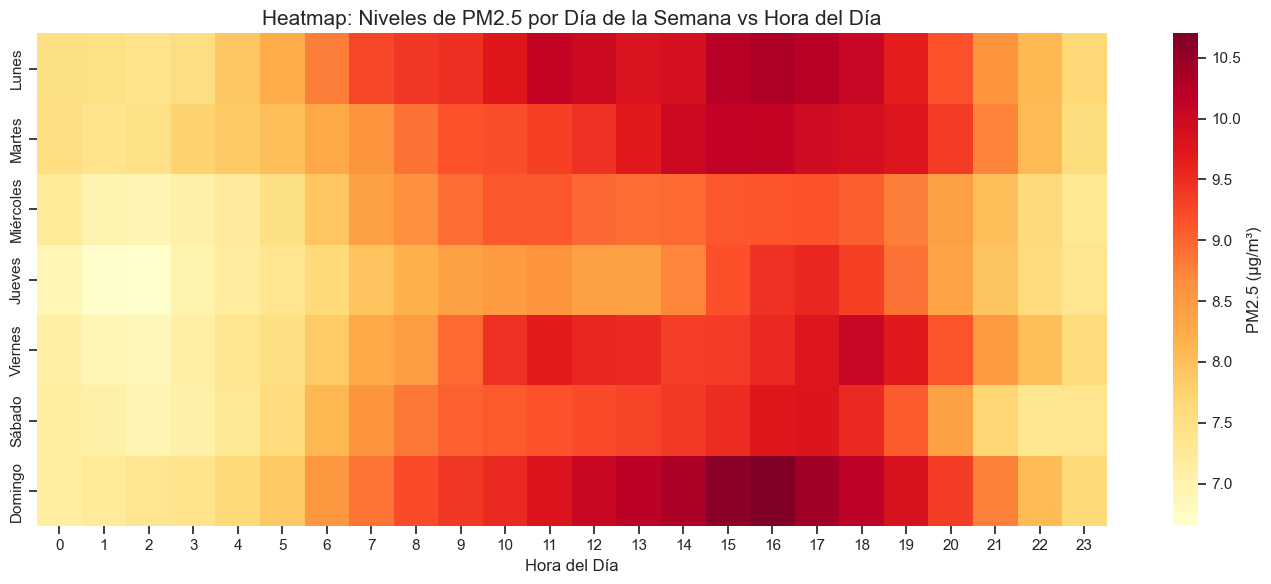

In [29]:
# Matriz: día de la semana vs hora
weekly_hourly = df.groupby(['day_of_week', 'hour'])['PM2.5'].mean().reset_index()
heatmap_data = weekly_hourly.pivot_table(index='day_of_week', columns='hour', values='PM2.5')

# Etiquetas de días (0=Lunes... 6=Domingo)
dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
heatmap_data.index = dias

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, fmt=".1f", cbar_kws={'label': 'PM2.5 (µg/m³)'})
plt.title("Heatmap: Niveles de PM2.5 por Día de la Semana vs Hora del Día", fontsize=15)
plt.xlabel("Hora del Día")
plt.ylabel("")
plt.tight_layout()
plt.savefig('../../outputs/figures/eda/heatmap_week_hour.png')
plt.show()


## 4. Variación Estacional (Boxplots Mensuales)

Distribución completa por meses, observaremos si el invierno (uso de calefacción, inversiones térmicas) genera mayores concentraciones que el verano.

C:\Users\Ivan\AppData\Local\Temp\ipykernel_556\1782994860.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='month', y='PM2.5', palette='viridis', showfliers=False)


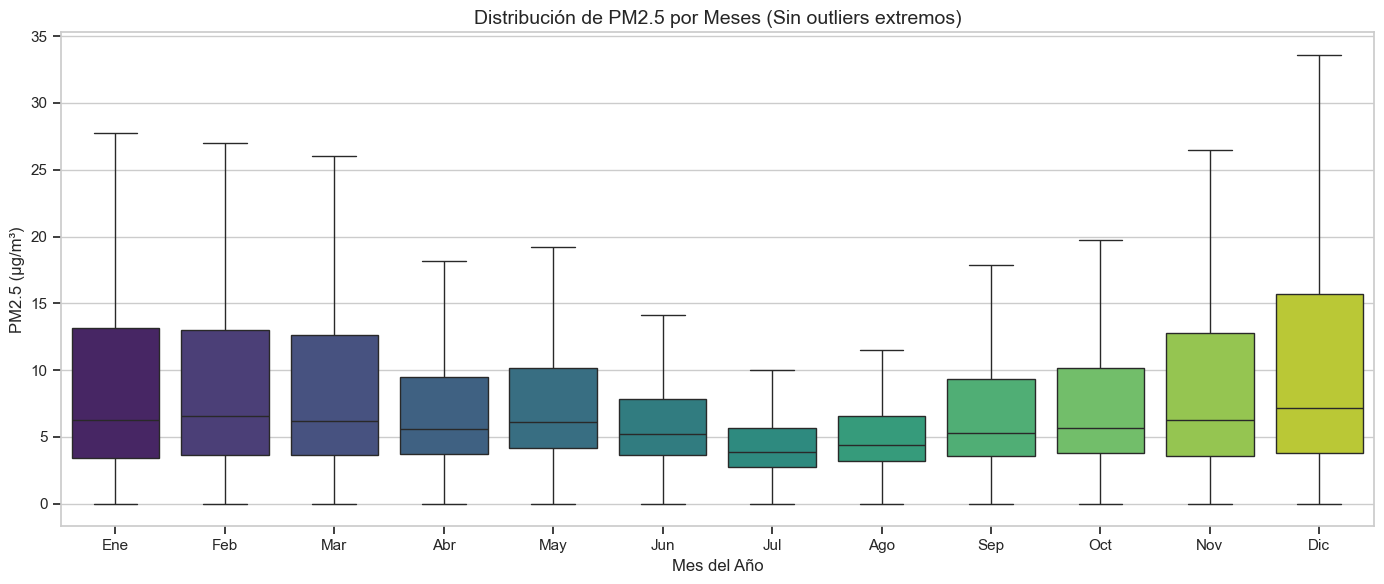

In [30]:
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='month', y='PM2.5', palette='viridis', showfliers=False)
plt.title("Distribución de PM2.5 por Meses (Sin outliers extremos)", fontsize=14)
plt.xlabel("Mes del Año")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(range(12), meses)
plt.tight_layout()
plt.savefig('../../outputs/figures/eda/boxplot_monthly.png')
plt.show()


## 5. Detección de Outliers Extremos o Anomalías (Eventos)

Veamos el **Top 10** de días más contaminados registrados a nivel ciudad, para buscar explicación (ej. Guy Fawkes Night, incendios, calima severa).

In [32]:
# Promedio global por días
daily_pollution = df.groupby('date')['PM2.5'].mean().reset_index()
top_10 = daily_pollution.sort_values(by='PM2.5', ascending=False).head(10)

print("Top 10 Días más contaminados a nivel de ciudad (Liverpool, PM2.5):")
display(top_10)

fig = px.line(daily_pollution, x='date', y='PM2.5', title='Media Diaria de PM2.5 con Outliers (Interactiva)')
fig.add_hline(y=15, line_dash='dash', line_color='red', annotation_text="Límite OMS 24h")
fig.show()


Top 10 Días más contaminados a nivel de ciudad (Liverpool, PM2.5):


,date,PM2.5
1378,2024-12-27,38.823370
311,2022-01-25,37.628574
278,2021-12-23,37.363139
622,2022-12-02,36.202731
282,2021-12-27,34.935325
275,2021-12-20,32.300851
368,2022-03-23,31.756716
348,2022-03-03,30.748030
371,2022-03-26,30.264093
633,2022-12-13,29.692640


In [33]:
# Añade esto después de crear daily_pollution
daily_pollution['PM2.5_smooth'] = daily_pollution['PM2.5'].rolling(window=7, center=True).mean()

# En el gráfico, usa la columna suavizada
fig = px.line(daily_pollution, x='date', y='PM2.5_smooth', title='Tendencia Suavizada (Media Móvil 7 días)')
fig.show()
